In [ ]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram



simulator = AerSimulator(method='statevector', device='CPU')

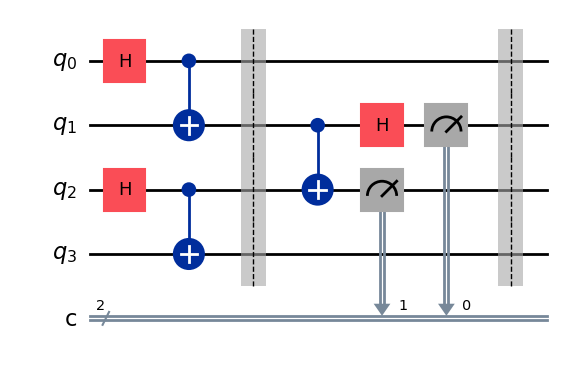

In [ ]:
qc = QuantumCircuit(4, 2)
 (2,3)
qc.h([0, 2])
qc.cx(0, 1)
qc.cx(2, 3)
qc.barrier()

qc.cx(1, 2)
qc.h(1)
qc.measure([1, 2], [0, 1])
qc.barrier()

qc.draw('mpl')

Circuit logic corrected using if_test context managers.


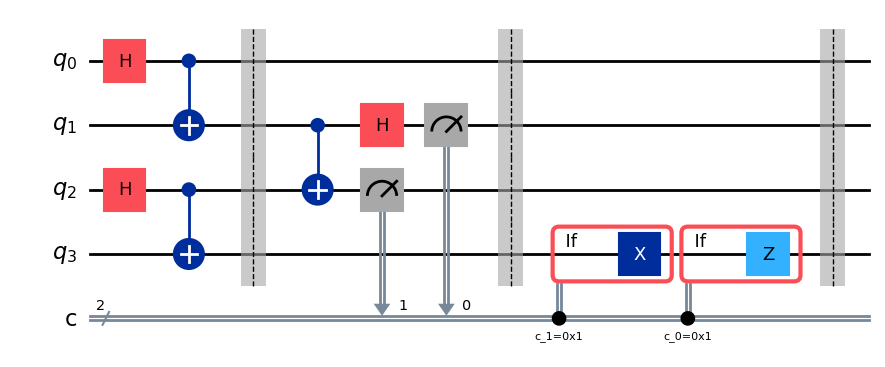

In [ ]:

with qc.if_test((qc.clbits[1], 1)):
    qc.x(3)

with qc.if_test((qc.clbits[0], 1)):
    qc.z(3)

qc.barrier()
print("Circuit logic corrected using if_test context managers.")
qc.draw('mpl')

In [ ]:
from qiskit.quantum_info import partial_trace, state_fidelity, Statevector


qc_swapped = qc.copy()
qc_swapped.save_statevector()


result = simulator.run(qc_swapped).result()
final_state = result.get_statevector()

rho_03 = partial_trace(final_state, [1, 2])

print("Reduced Density Matrix for qubits 0 and 3:")
display(rho_03.draw('latex'))

print(f"Purity of final pair: {rho_03.purity().real:.4f}")

Reduced Density Matrix for qubits 0 and 3:


<IPython.core.display.Latex object>

Purity of final pair: 1.0000


In [ ]:
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

zero_zero = Statevector.from_label('00')
one_one = Statevector.from_label('11')

ideal_bell = (1/np.sqrt(2)) * (zero_zero + one_one)

fidelity = state_fidelity(rho_03, ideal_bell)

print(f"VERIFIED: State Fidelity = {fidelity:.4f}")

if fidelity > 0.95:
    print("Success: Entanglement has been verified across the swap.")
else:
    print("Skeptical Result: Fidelity is too low. Check for decoherence in your simulator settings.")

VERIFIED: State Fidelity = 1.0000
Success: Entanglement has been verified across the swap.
